# 3D Sphere Plotting with Convex Hull

In [4]:
from typing import Any

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from lds_gen.lds import Sphere

 Luk ???

 from mpl_toolkits.mplot3d import Axes3D

0.28834045210327514
0.49278361015103833


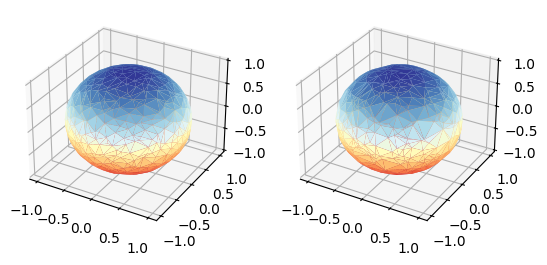

In [5]:
from scipy.spatial import ConvexHull

from sphere_n.discrep_2 import discrep_2


def average_g(triples: np.ndarray) -> float:
    return np.mean([triple[2] for triple in triples])


def sample_spherical(npoints: int, ndim: int = 3) -> np.ndarray:
    vec = np.random.randn(ndim, npoints)
    vec /= np.linalg.norm(vec, axis=0)
    return vec.transpose()


def my_plot(Triples: np.ndarray, ax: Any) -> None:
    hull = ConvexHull(Triples)
    triangles = hull.simplices
    measure = discrep_2(triangles, Triples)
    print(measure)

    colors = np.array(
        [
            average_g(np.array([Triples[idx] for idx in triangle]))
            for triangle in triangles
        ]
    )

    X = Triples[:, 0]
    Y = Triples[:, 1]
    Z = Triples[:, 2]

    collec = ax.plot_trisurf(
        mtri.Triangulation(X, Y, triangles),
        Z,
        shade=False,
        cmap=plt.get_cmap("RdYlBu"),
        array=colors,
    )
    collec.autoscale()


def main() -> None:
    # Triples = np.array(list(zip(X, Y, Z)))
    npoints = 600

    fig = plt.figure()
    ax1 = fig.add_subplot(121, projection="3d")
    ax2 = fig.add_subplot(122, projection="3d")

    sgen = Sphere([2, 3])
    # points = [sgen.pop() for _ in range(npoints)]
    Triples = np.array([sgen.pop() for _ in range(npoints)])
    # Triples = np.array([p for p in sphere(npoints, [2, 3, 5])])
    my_plot(Triples, ax1)
    Triples = sample_spherical(npoints)
    my_plot(Triples, ax2)
    plt.show()

    # plt.plot(points[:,0], points[:,1], 'o')
    # plt.plot(points[hull.vertices,0], points[hull.vertices,1], 'r--', lw=2)
    # plt.show()


if __name__ == "__main__":
    main()